In [61]:
#This notebook is about decision tree classification using car evaluation dataset.
# We will use the dataset to train a decision tree classifier and evaluate its performance.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [62]:
df=pd.read_csv("car_evaluation.csv")
df.head(10)

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
5,vhigh,vhigh,2,2,big,low,unacc
6,vhigh,vhigh,2,2,big,med,unacc
7,vhigh,vhigh,2,2,big,high,unacc
8,vhigh,vhigh,2,4,small,low,unacc
9,vhigh,vhigh,2,4,small,med,unacc


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [64]:
col_names=["buying","maint","doors","persons","lug_boot","safety","class"]
df.columns=col_names
df.head(10)

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
5,vhigh,vhigh,2,2,big,low,unacc
6,vhigh,vhigh,2,2,big,med,unacc
7,vhigh,vhigh,2,2,big,high,unacc
8,vhigh,vhigh,2,4,small,low,unacc
9,vhigh,vhigh,2,4,small,med,unacc


In [65]:
for col in df.columns:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [66]:
df["doors"].unique()

array(['2', '3', '4', '5more'], dtype=object)

In [67]:
df['doors']=df['doors'].replace('5more',5)
df['doors']=df['doors'].astype(int)
df["doors"].unique()

array([2, 3, 4, 5])

In [68]:
df["persons"].unique()

array(['2', '4', 'more'], dtype=object)

In [69]:
df['persons']=df['persons'].replace('more',5)
df['persons']=df['persons'].astype(int)
df["persons"].unique()

array([2, 4, 5])

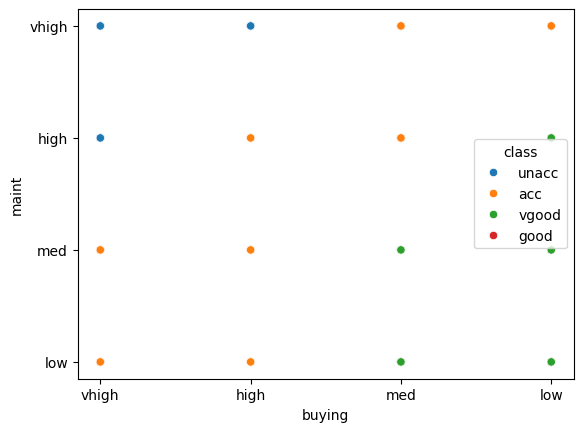

In [70]:
sns.scatterplot(x=df["buying"],y=df["maint"],hue=df["class"])
plt.show()

In [71]:
X=df.drop("class", axis=1)
y=df["class"]

In [72]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=34)

In [73]:
#Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [75]:
numeric_cols=["doors","persons"]
categorical_cols=["buying","maint","lug_boot","safety"] 
encoder=OrdinalEncoder(categories=[
    ["low","med","high","vhigh"], #buying
    ["low","med","high","vhigh"], #maint
    ["small","med","big"], #lug_boot
    ["low","med","high"]  #safety
])

#We can also use ColumnTransformer to apply different transformations to different columns, but in this case we only have one type of transformation (ordinal encoding) for the categorical columns and we want to pass through the numeric columns without any transformation. 
#So we can simply use the encoder without the need for a ColumnTransformer.
preprocessor=ColumnTransformer(transformers=[
   ('trans', encoder, categorical_cols),
], remainder="passthrough")


X_train_encoded=preprocessor.fit_transform(X_train)
X_test_encoded=preprocessor.transform(X_test)

In [76]:
pd.DataFrame(X_train_encoded)

,0,1,2,3,4,5
0,3.0,1.0,2.0,1.0,4.0,5.0
1,2.0,2.0,0.0,1.0,4.0,4.0
2,3.0,2.0,0.0,2.0,4.0,5.0
3,0.0,1.0,0.0,2.0,5.0,4.0
4,3.0,3.0,2.0,1.0,2.0,5.0
...,...,...,...,...,...,...
1203,3.0,0.0,0.0,1.0,2.0,2.0
1204,1.0,1.0,1.0,0.0,3.0,2.0
1205,2.0,3.0,1.0,2.0,4.0,2.0
1206,1.0,1.0,1.0,1.0,4.0,4.0


In [77]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="gini", max_depth=3,random_state=34)
model.fit(X_train_encoded,y_train)
y_pred=model.predict(X_test_encoded)

In [78]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

         acc       0.51      0.48      0.49       109
        good       0.00      0.00      0.00        18
       unacc       0.86      0.97      0.91       371
       vgood       0.00      0.00      0.00        21

    accuracy                           0.79       519
   macro avg       0.34      0.36      0.35       519
weighted avg       0.72      0.79      0.76       519

Confusion Matrix:
 [[ 52   0  57   0]
 [ 18   0   0   0]
 [ 11   0 360   0]
 [ 21   0   0   0]]
Accuracy Score: 0.7938342967244701


c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sudet\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

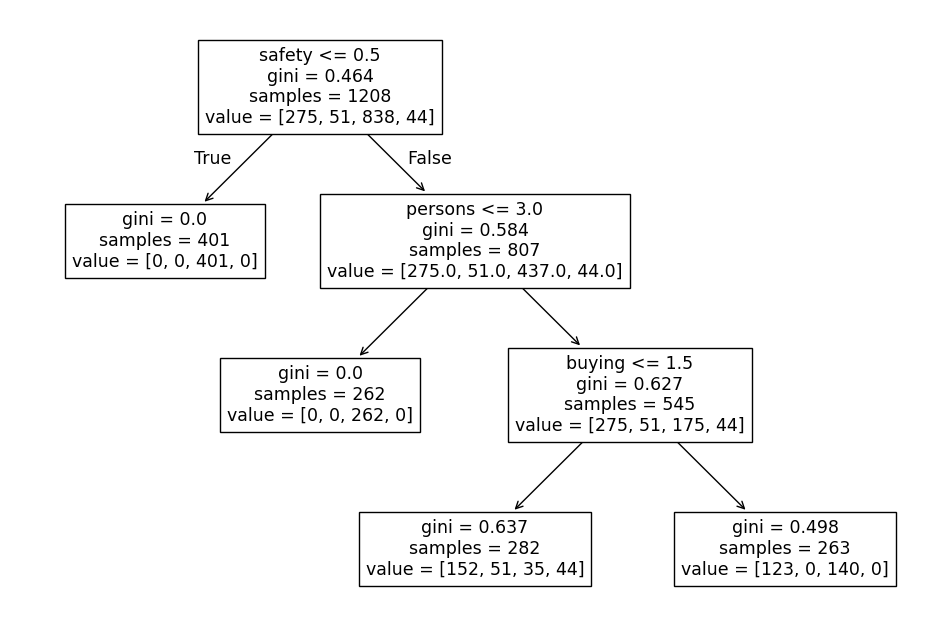

In [81]:
#Visualize the decision tree
plt.figure(figsize=(12,8))
from sklearn import tree
tree.plot_tree(model.fit(X_train_encoded, y_train), feature_names=categorical_cols+numeric_cols)
plt.show()

In [82]:
#hyperparameter tuning
param={
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [1,2,3,4,5,15, None],
    "max_features": [None, "sqrt", "log2"]
}

In [83]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param, cv=5,scoring="accuracy")
import warnings
warnings.filterwarnings("ignore")
grid.fit(X_train_encoded, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': [None, 'sqrt', ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [85]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'splitter': 'best'}

In [86]:
y_pred2=grid.predict(X_test_encoded)
print("Classification Report:\n", classification_report(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("Accuracy Score:", accuracy_score(y_test, y_pred2))

Classification Report:
               precision    recall  f1-score   support

         acc       0.90      0.95      0.93       109
        good       0.84      0.89      0.86        18
       unacc       0.99      0.98      0.98       371
       vgood       0.94      0.81      0.87        21

    accuracy                           0.96       519
   macro avg       0.92      0.91      0.91       519
weighted avg       0.96      0.96      0.96       519

Confusion Matrix:
 [[104   1   3   1]
 [  1  16   1   0]
 [  6   2 363   0]
 [  4   0   0  17]]
Accuracy Score: 0.9633911368015414


In [87]:
tree_model_new=DecisionTreeClassifier(criterion="entropy",max_depth=None,max_features=None,splitter="best")
tree_model_new.fit(X_train_encoded, y_train)
y_pred_new=tree_model_new.predict(X_test_encoded)
print("Classification Report:\n", classification_report(y_test, y_pred_new))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_new))
print("Accuracy Score:", accuracy_score(y_test, y_pred_new))

Classification Report:
               precision    recall  f1-score   support

         acc       0.91      0.96      0.93       109
        good       0.84      0.89      0.86        18
       unacc       0.99      0.98      0.98       371
       vgood       1.00      0.86      0.92        21

    accuracy                           0.97       519
   macro avg       0.93      0.92      0.93       519
weighted avg       0.97      0.97      0.97       519

Confusion Matrix:
 [[105   1   3   0]
 [  1  16   1   0]
 [  7   2 362   0]
 [  3   0   0  18]]
Accuracy Score: 0.9653179190751445


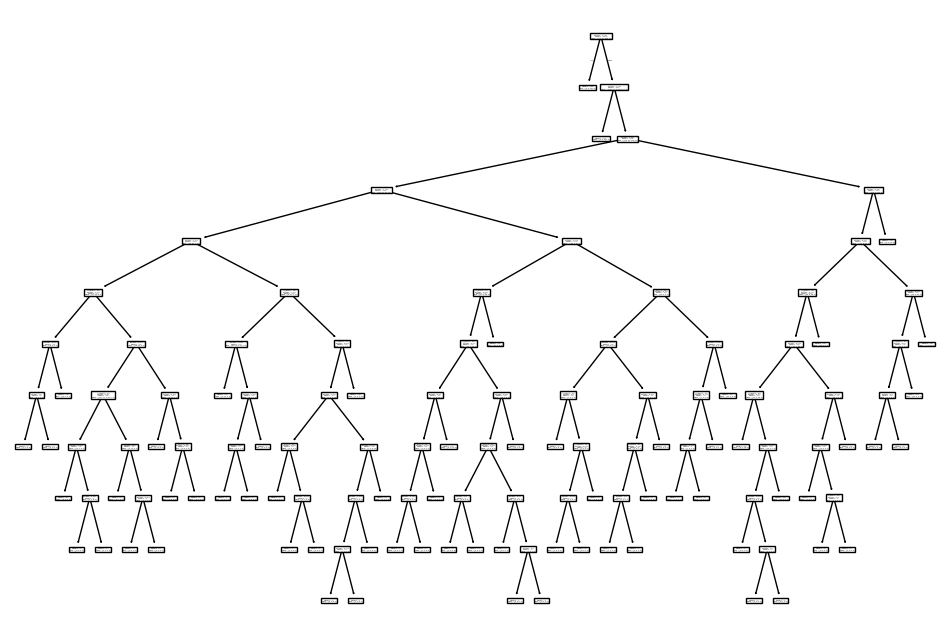

In [88]:
plt.figure(figsize=(12,8))
from sklearn import tree
tree.plot_tree(tree_model_new.fit(X_train_encoded, y_train), feature_names=categorical_cols+numeric_cols)
plt.show()

In [ ]:
#As we can see without max_depth tree goes on and on, this may seem to increase accuracy in this dataset
#However in another example it may definetely increase chance of overfitting, so we need pruning.
#We can do prepruning or postpruning, playing with max_depth parameter. that's why i chose max_depth 3 to show you to begin with

In [94]:
df_new = pd.read_csv("iris.csv")
df_new.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


[Text(0.4, 0.9285714285714286, 'PetalLengthCm <= 2.45\ngini = 0.662\nsamples = 120\nvalue = [39, 35, 46]'),
 Text(0.3, 0.7857142857142857, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(0.35, 0.8571428571428572, 'True  '),
 Text(0.5, 0.7857142857142857, 'PetalLengthCm <= 4.85\ngini = 0.491\nsamples = 81\nvalue = [0, 35, 46]'),
 Text(0.45, 0.8571428571428572, '  False'),
 Text(0.2, 0.6428571428571429, 'PetalWidthCm <= 1.65\ngini = 0.059\nsamples = 33\nvalue = [0, 32, 1]'),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 31\nvalue = [0, 31, 0]'),
 Text(0.3, 0.5, 'SepalLengthCm <= 5.4\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.2, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.4, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.8, 0.6428571428571429, 'PetalWidthCm <= 1.75\ngini = 0.117\nsamples = 48\nvalue = [0, 3, 45]'),
 Text(0.7, 0.5, 'PetalLengthCm <= 5.35\ngini = 0.49\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.6, 0.357

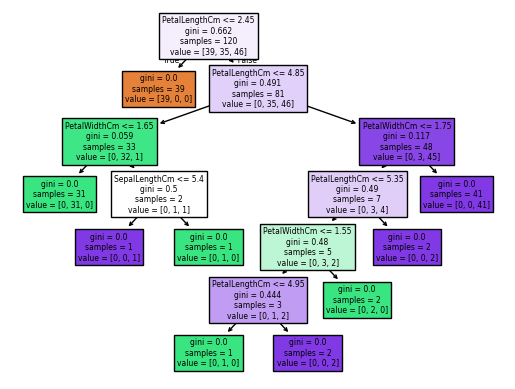

In [95]:
X=df_new.drop(["Id", "Species"], axis=1)
y=df_new["Species"]
X_trainnew, X_testnew, y_trainnew, y_testnew = train_test_split(X, y, test_size=0.2, random_state=34)
tree_model = DecisionTreeClassifier()
tree_model.fit(X_trainnew, y_trainnew)
tree.plot_tree(tree_model, feature_names=X_trainnew.columns, filled=True)

In [96]:
y_prednew = tree_model.predict(X_testnew)
print(accuracy_score(y_testnew, y_prednew))
print(confusion_matrix(y_testnew, y_prednew))
print(classification_report(y_testnew, y_prednew))

0.9333333333333333
[[11  0  0]
 [ 0 15  0]
 [ 0  2  2]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.50      0.67         4

       accuracy                           0.93        30
      macro avg       0.96      0.83      0.87        30
   weighted avg       0.94      0.93      0.92        30



In [97]:
tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_trainnew, y_trainnew)
y_prednew = tree_model.predict(X_testnew)
print(accuracy_score(y_testnew, y_prednew))
print(confusion_matrix(y_testnew, y_prednew))
print(classification_report(y_testnew, y_prednew))

0.9
[[11  0  0]
 [ 0 14  1]
 [ 0  2  2]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.88      0.93      0.90        15
 Iris-virginica       0.67      0.50      0.57         4

       accuracy                           0.90        30
      macro avg       0.85      0.81      0.82        30
   weighted avg       0.89      0.90      0.89        30



[Text(0.375, 0.875, 'PetalWidthCm <= 0.8\ngini = 0.662\nsamples = 120\nvalue = [39, 35, 46]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'PetalLengthCm <= 4.85\ngini = 0.491\nsamples = 81\nvalue = [0, 35, 46]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'SepalLengthCm <= 4.95\ngini = 0.059\nsamples = 33\nvalue = [0, 32, 1]'),
 Text(0.125, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 31\nvalue = [0, 31, 0]'),
 Text(0.75, 0.375, 'PetalWidthCm <= 1.75\ngini = 0.117\nsamples = 48\nvalue = [0, 3, 45]'),
 Text(0.625, 0.125, 'gini = 0.49\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 41\nvalue = [0, 0, 41]')]

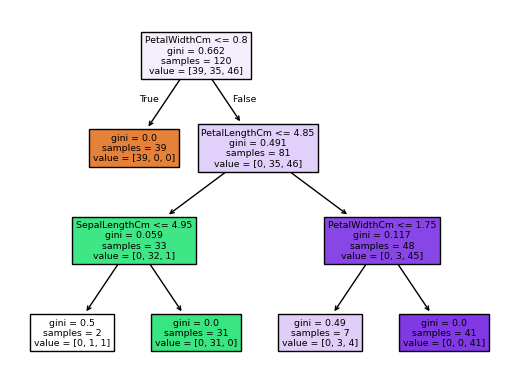

In [98]:
tree.plot_tree(tree_model.fit(X_trainnew, y_trainnew),feature_names=X_trainnew.columns, filled=True)